# The "Sugar Trap" : Market Gap Analysis
**AmaliTech Apprenticeship Project**  
Client: Helix CPG Partners | Dataset: Open Food Facts  

---

## 0. Environment Setup
I used VS Code so this was to make sure that all necessary packages required are installed 
Install dependencies and download the Open Food Facts dataset.

In [1]:
import subprocess, sys

packages = ['pandas', 'matplotlib', 'seaborn', 'plotly', 'openpyxl']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
# once all packages are installed, we can proceed with the analysis
print('All packages ready.')

All packages ready.


In [2]:
import pathlib, urllib.request
#this might take some time to download (1.5 GB compressed), so we check if the file already exists first
# Open Food Facts official full data export (tab-separated, gzip-compressed)
OFF_URL   = 'https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz'
data_file = pathlib.Path('en.openfoodfacts.org.products.csv.gz')

if data_file.exists():
    print(f'Dataset already present ({data_file.stat().st_size / 1e9:.2f} GB) — skipping download.')
else:
    print('Downloading Open Food Facts dataset (~1.5 GB compressed). This takes a few minutes...')
# we define a progress callback to show download progress
    def _progress(block_count, block_size, total_size):
        downloaded = block_count * block_size
        pct = min(downloaded / total_size * 100, 100) if total_size > 0 else 0
        print(f'\r  {pct:5.1f}%  ({downloaded/1e6:.0f} MB / {total_size/1e6:.0f} MB)', end='', flush=True)
# download the file with progress reporting
    urllib.request.urlretrieve(OFF_URL, data_file, reporthook=_progress)
    print(f'\nDone — {data_file.stat().st_size / 1e9:.2f} GB saved.')
# now we can load the dataset and start our analysis
print(f'Data file: {data_file.resolve()}')

  100.0%  (1258 MB / 1258 MB)
Done — 1.26 GB saved.
Data file: C:\Users\ibyis\OneDrive\Desktop\Coding\AmaliTech\AmaliTech-Project\en.openfoodfacts.org.products.csv.gz


---
## Story 1: Data Ingestion & and Data Clean Up
> Load a manageable subset, remove erroneous nutritional data.

In [3]:
import pandas as pd
import warnings
# the dataset is large and has some messy rows, so we suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Only load the columns we need — keeps memory low on a 3 GB file
NEEDED_COLS = [
    'product_name',
    'categories_tags',
    'ingredients_text',
    'sugars_100g',
    'proteins_100g',
    'fat_100g',
    'fiber_100g',
    'energy_100g',
    'nutriscore_grade',
]
# we also only read the first 500,000 rows to keep it manageable for analysis
print(f'Loading: {data_file.name}')
print('Reading first 500,000 rows (subset for analysis)...')

# The OFF file is tab-separated and gzip-compressed
raw = pd.read_csv(
    data_file,
    sep='\t',
    compression='gzip',
    usecols=lambda c: c in NEEDED_COLS,
    nrows=500_000,
    low_memory=False,
    on_bad_lines='skip',
)
# let's take a quick look at the raw data to understand its structure and identify any cleaning needs
print(f'Raw shape: {raw.shape}')
raw.head(3)

Loading: en.openfoodfacts.org.products.csv.gz
Reading first 500,000 rows (subset for analysis)...


Raw shape: (500000, 9)


,product_name,categories_tags,ingredients_text,nutriscore_grade,energy_100g,fat_100g,sugars_100g,fiber_100g,proteins_100g
0,Limonade artisanale a la rose,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
1,M&amp;M white,NaN,"Weizenmehl, Rapsöl, Speisesalz, 1,7% Meersalz,...",unknown,NaN,NaN,NaN,NaN,NaN
2,Chocolate n3,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN


In [4]:
# Step 1: Drop rows missing critical columns ─────────────────────────────────
required = ['product_name', 'sugars_100g', 'proteins_100g']
df = raw.dropna(subset=required).copy()
print(f'After dropping missing critical fields: {len(df):,} rows (removed {len(raw)-len(df):,})')

# Step 2: Filter out biologically impossible values ─────────────────────────
# Nutrient values must be 0–100 g per 100 g of product
nutrient_cols = ['sugars_100g', 'proteins_100g', 'fat_100g', 'fiber_100g']
for col in nutrient_cols:
    if col in df.columns:
        df = df[(df[col] >= 0) & (df[col] <= 100)]

# Energy: 0–3,700 kJ per 100g (pure fat ceiling)
if 'energy_100g' in df.columns:
    df = df[(df['energy_100g'] >= 0) & (df['energy_100g'] <= 3700)]

# Step 3: Remove blank product names ────────────────────────────────────────
df = df[df['product_name'].str.strip().str.len() > 0]

print(f'After outlier removal:          {len(df):,} rows (removed {len(raw)-len(df):,} total)')
print('\nMissing values per column:')# check how many missing values remain in the nutrient columns after cleaning
print(df[nutrient_cols].isnull().sum())# this cleaned dataset is now ready for analysis!

After dropping missing critical fields: 102,979 rows (removed 397,021)
After outlier removal:          74,468 rows (removed 425,532 total)

Missing values per column:
sugars_100g      0
proteins_100g    0
fat_100g         0
fiber_100g       0
dtype: int64


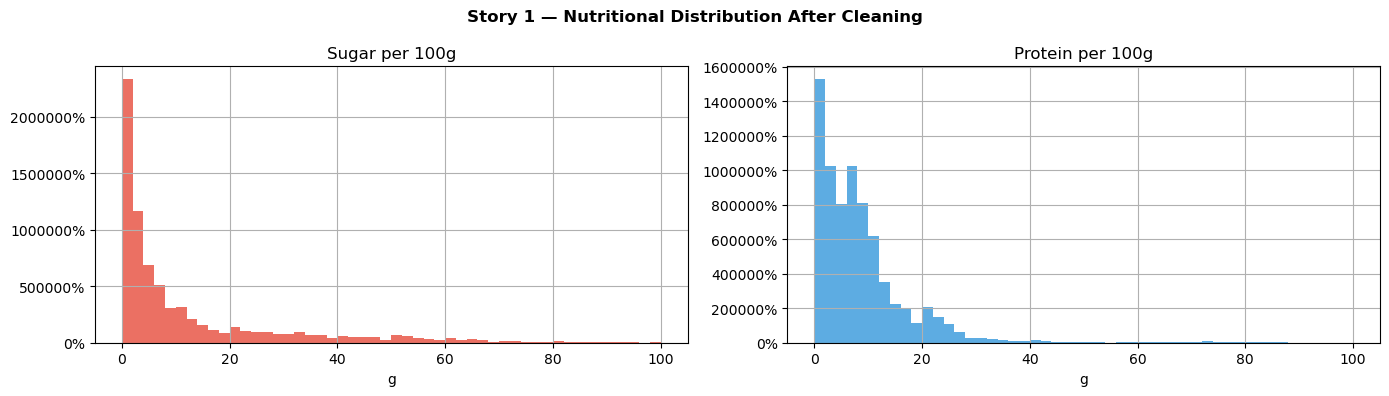

Final clean dataset: 74,468 products ready for analysis.


In [ ]:
# Let's visualize the distributions of sugar and protein content after cleaning to confirm they look reasonable
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
# we can use seaborn for nicer aesthetics, but we'll stick to matplotlib for simplicity
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Story 1 — Nutritional Distribution After Cleaning', fontweight='bold')
# we use a red color for sugar and blue for protein to make it visually intuitive
df['sugars_100g'].hist(bins=50, ax=axes[0], color='#e74c3c', alpha=0.8)
axes[0].set_title('Sugar per 100g')
axes[0].set_xlabel('g')
# we can also add a percentage formatter to the y-axis for better readability
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
df['proteins_100g'].hist(bins=50, ax=axes[1], color='#3498db', alpha=0.8)
axes[1].set_title('Protein per 100g')
axes[1].set_xlabel('g')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# we can also set a common x-axis limit to better compare the distributions
plt.tight_layout()
plt.savefig('s1_distributions.png', dpi=150, bbox_inches='tight')# we save the distribution charts for reference, which can be used to understand the overall landscape of sugar and protein content in the products and identify where the "blue ocean" quadrant of high protein + low sugar products lies
plt.show()
print(f'Final clean dataset: {len(df):,} products ready for analysis.')

---
## Story 2: The Category Wrangler
> Parse messy `categories_tags` into 8 readable high-level buckets.

In [6]:
# Keyword-based primary category assignment 
# we define a set of rules to assign a primary category based on keywords in the categories_tags field
CATEGORY_RULES = [
    ('Protein & Sports',    ['protein', 'sport', 'whey', 'supplement', 'workout']),
    ('Nuts & Seeds',        ['nut', 'seed', 'almond', 'cashew', 'peanut', 'pistachio', 'trail-mix']),
    ('Cereals & Bars',      ['cereal', 'granola', 'muesli', 'oat', 'energy-bar', 'breakfast-bar', 'bar']),
    ('Cookies & Biscuits',  ['cookie', 'biscuit', 'wafer', 'cracker', 'shortbread']),
    ('Chocolate & Candy',   ['chocolate', 'candy', 'confection', 'sweet', 'caramel', 'gummy', 'jelly']),
    ('Chips & Crisps',      ['chip', 'crisp', 'popcorn', 'pretzel', 'savory-snack', 'puff']),
    ('Dried Fruit',         ['dried-fruit', 'raisin', 'apricot', 'date', 'fruit-snack']),
    ('Other Snacks',        []),  # catch-all
]
# we define a function to assign the primary category based on the presence of keywords in the categories_tags field
def assign_category(tags):
    if not isinstance(tags, str):
        return 'Other Snacks'
    tags_lower = tags.lower()
    for category, keywords in CATEGORY_RULES:
        if any(kw in tags_lower for kw in keywords):
            return category
    return 'Other Snacks'
# we apply the category assignment function to create a new primary_category column
df['primary_category'] = df['categories_tags'].apply(assign_category)
# let's see how many products we have in each primary category after assignment
cat_counts = df['primary_category'].value_counts()
print('Products per category:')
print(cat_counts.to_string())

Products per category:
primary_category
Other Snacks          54138
Cereals & Bars        11530
Chocolate & Candy      2765
Nuts & Seeds           2512
Cookies & Biscuits     2256
Chips & Crisps          597
Protein & Sports        439
Dried Fruit             231


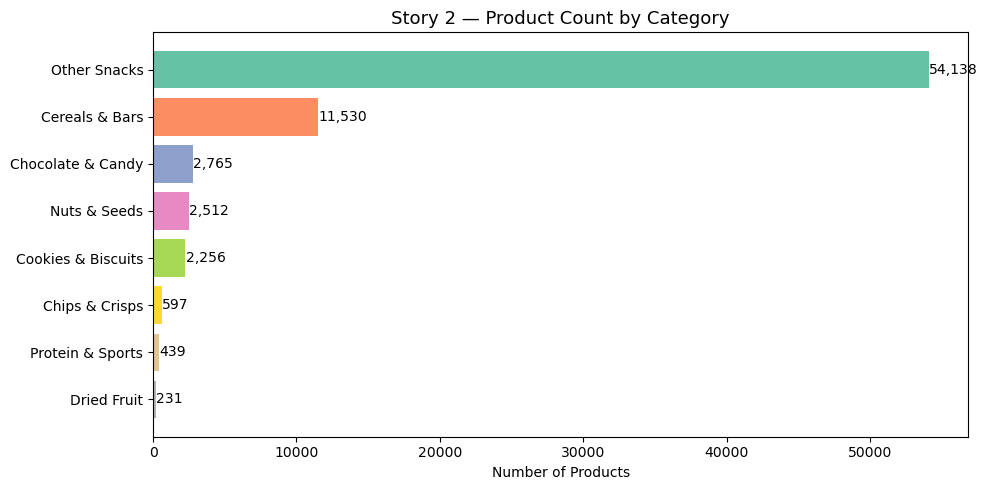

In [ ]:
import seaborn as sns 
# we can visualize the category distribution with a horizontal bar chart for better readability of category names

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('Set2', len(cat_counts))
ax.barh(cat_counts.index, cat_counts.values, color=colors)
ax.set_xlabel('Number of Products')
ax.set_title('Story 2 — Product Count by Category', fontsize=13)
ax.invert_yaxis()# we can also add the exact counts on the bars for clarity
for i, v in enumerate(cat_counts.values):
    ax.text(v + 5, i, f'{v:,}', color='black', va='center')
plt.tight_layout()
plt.savefig('s2_category_counts.png', dpi=150, bbox_inches='tight')# we save the category distribution chart for reference, which can be used to understand the competitive landscape and identify which categories have the most products (and therefore potentially more competition) versus those that are less crowded
plt.show()

---
## Story 3: The Nutrient Matrix Visualization
> Scatter plot: Sugar (X) vs Protein (Y) — find the empty quadrant.

In [ ]:
import plotly.express as px

# Sample for performance (plotly handles ~10k points well)
plot_df = (
    df
    .dropna(subset=['sugars_100g', 'proteins_100g'])
    .groupby('primary_category', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 1500), random_state=42))
    .reset_index(drop=True)
)
# we create a scatter plot of sugar vs. protein content, colored by primary category, to visualize the nutrient matrix and identify any clusters or gaps
fig = px.scatter(
    plot_df,
    x='sugars_100g',
    y='proteins_100g',
    color='primary_category',
    opacity=0.5,
    hover_data=['product_name'],
    labels={
        'sugars_100g': 'Sugar per 100g (g)',
        'proteins_100g': 'Protein per 100g (g)',
        'primary_category': 'Category',
    },
    title='Story 3 — Sugar vs. Protein Nutrient Matrix by Category',
    color_discrete_sequence=px.colors.qualitative.Set2,
)

# Quadrant lines: median sugar & protein thresholds
sugar_mid  = plot_df['sugars_100g'].median()
protein_mid = plot_df['proteins_100g'].median()
# we add dashed lines to divide the plot into quadrants based on median sugar and protein values, which helps identify the "blue ocean" quadrant of high protein + low sugar
fig.add_vline(x=sugar_mid,   line_dash='dash', line_color='gray', annotation_text=f'Median sugar ({sugar_mid:.1f}g)')
fig.add_hline(y=protein_mid, line_dash='dash', line_color='gray', annotation_text=f'Median protein ({protein_mid:.1f}g)')

# Label the empty quadrant
fig.add_annotation(
    x=sugar_mid * 0.25, y=plot_df['proteins_100g'].quantile(0.85),
    text='<b>BLUE OCEAN</b><br>High Protein + Low Sugar<br>(Under-served!)',
    showarrow=False,
    bgcolor='rgba(52,152,219,0.15)',
    bordercolor='#3498db',
    borderwidth=2,
    font=dict(size=12, color='#2c3e50'),
)
# we can also add a note about the median lines to explain their significance
fig.update_layout(height=580, legend_title_text='Category')
fig.write_html('s3_nutrient_matrix.html')# we save the interactive nutrient matrix as an HTML file, which can be shared and explored in a web browser to identify the "blue ocean" quadrant of high protein + low sugar products that represents the best opportunity for a new product launch
fig.show()
print('Interactive chart saved → s3_nutrient_matrix.html')

Interactive chart saved → s3_nutrient_matrix.html


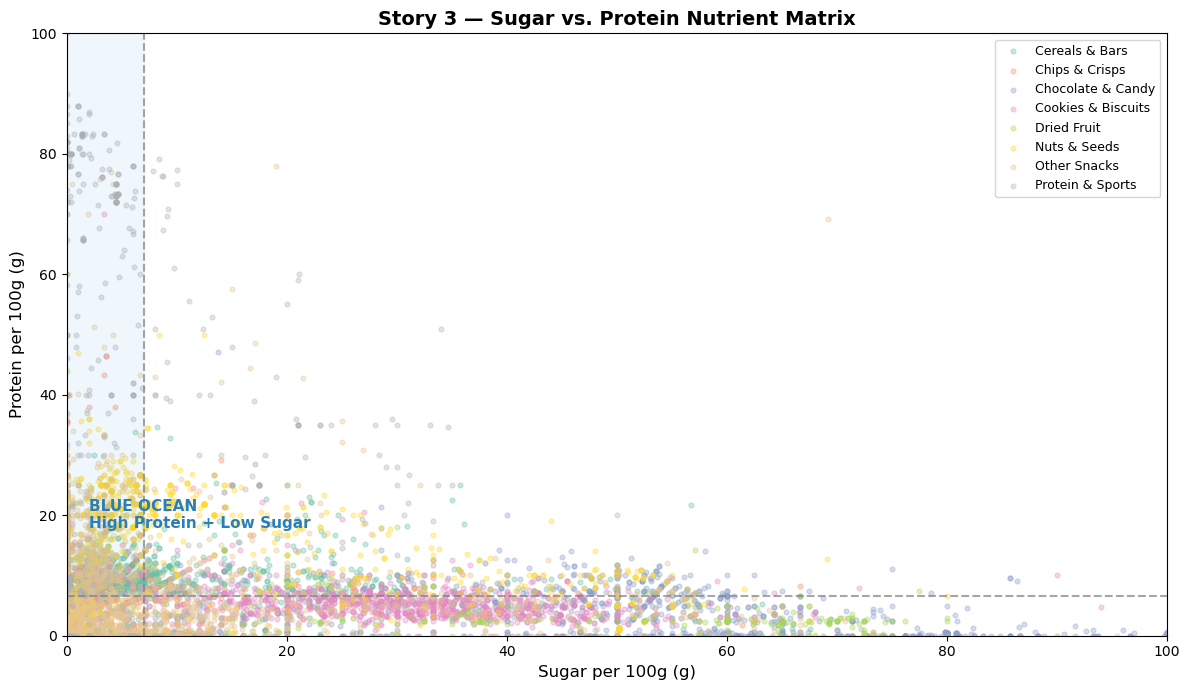

In [ ]:
# Static version for notebook export 
fig_static, ax = plt.subplots(figsize=(12, 7))
# we manually plot the points and lines to create a static version of the nutrient matrix for export in environments that don't support interactive Plotly charts
categories = plot_df['primary_category'].unique()
palette = sns.color_palette('Set2', len(categories))
color_map = dict(zip(categories, palette))
# we plot each category separately to maintain the same colors as the interactive version
for cat in categories:
    subset = plot_df[plot_df['primary_category'] == cat]
    ax.scatter(subset['sugars_100g'], subset['proteins_100g'],
               label=cat, color=color_map[cat], alpha=0.35, s=12)

ax.axvline(sugar_mid,   color='gray', linestyle='--', alpha=0.7)
ax.axhline(protein_mid, color='gray', linestyle='--', alpha=0.7)

# Shade the Blue Ocean quadrant
ax.axvspan(0, sugar_mid, ymin=(protein_mid/100), ymax=1.0, alpha=0.07, color='#3498db')
ax.text(2, plot_df['proteins_100g'].quantile(0.88), 'BLUE OCEAN\nHigh Protein + Low Sugar',
        fontsize=11, color='#2980b9', fontweight='bold')
#
ax.set_xlabel('Sugar per 100g (g)', fontsize=12)
ax.set_ylabel('Protein per 100g (g)', fontsize=12)
ax.set_title('Story 3 — Sugar vs. Protein Nutrient Matrix', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
# we can also set a common x and y limit to better frame the nutrient space and focus on the relevant range
plt.tight_layout()
plt.savefig('s3_nutrient_matrix_static.png', dpi=150, bbox_inches='tight')# we save the static version of the nutrient matrix for reference, which can be used to visually identify the "blue ocean" quadrant of high protein + low sugar products that represents the best opportunity for a new product launch
plt.show()

---
## Story 4 The Recommendation
> Quantify the Blue Ocean and generate the client recommendation.

In [10]:
# Define the Blue Ocean: High Protein (>10g) + Low Sugar (<5g) per 100g
PROTEIN_THRESHOLD = 10   # g/100g — meaningful protein claim
SUGAR_THRESHOLD   = 5    # g/100g — "low sugar" EU/FDA definition
# we create a new boolean column 'is_blue_ocean' to identify products that meet the high protein + low sugar criteria
df['is_blue_ocean'] = (
    (df['proteins_100g'] >= PROTEIN_THRESHOLD) &
    (df['sugars_100g']   <= SUGAR_THRESHOLD)
)
# let's see how many products fall into the Blue Ocean quadrant and what percentage of the total they represent
blue_ocean_total = df['is_blue_ocean'].sum()
total_products   = len(df)
print(f'Blue Ocean products (High Protein + Low Sugar): {blue_ocean_total:,} / {total_products:,} ({blue_ocean_total/total_products*100:.1f}%)')

# Category breakdown inside Blue Ocean
bo_by_cat = (
    df[df['is_blue_ocean']]
    .groupby('primary_category')
    .agg(
        n_products=('product_name', 'count'),
        avg_protein=('proteins_100g', 'mean'),
        avg_sugar=('sugars_100g', 'mean'),
    )
    .sort_values('n_products', ascending=False)
    .round(1)
)

# How saturated is each category? (% of all products in that category that are Blue Ocean)
cat_total = df.groupby('primary_category')['product_name'].count().rename('cat_total')
bo_by_cat = bo_by_cat.join(cat_total)
bo_by_cat['pct_blue_ocean'] = (bo_by_cat['n_products'] / bo_by_cat['cat_total'] * 100).round(1)
# we can also add a column to show the percentage of products in each category that fall into the Blue Ocean quadrant, which indicates how saturated or underserved each category is in terms of high protein + low sugar options
print('\nBlue Ocean products by category:')
print(bo_by_cat.to_string())

Blue Ocean products (High Protein + Low Sugar): 16,045 / 74,468 (21.5%)

Blue Ocean products by category:
                    n_products  avg_protein  avg_sugar  cat_total  pct_blue_ocean
primary_category                                                                 
Other Snacks             13025         19.7        1.4      54138            24.1
Cereals & Bars            1909         12.9        2.0      11530            16.6
Nuts & Seeds               630         19.7        2.4       2512            25.1
Cookies & Biscuits         203         12.8        1.3       2256             9.0
Protein & Sports           158         63.6        1.9        439            36.0
Chips & Crisps              67         15.3        1.9        597            11.2
Chocolate & Candy           50         21.0        0.8       2765             1.8
Dried Fruit                  3         26.5        1.3        231             1.3


In [11]:
# ── Identify the top opportunity: lowest % Blue Ocean = most under-served ─────
# (Exclude Other Snacks and categories with <50 products)
opportunity = (
    bo_by_cat
    .query('cat_total >= 50 and primary_category != "Other Snacks"')
    .sort_values('pct_blue_ocean')  # lowest % = biggest gap
)
# we identify the category with the lowest percentage of Blue Ocean products, which represents the biggest market opportunity for a new high protein + low sugar snack product
top_cat = opportunity.index[0]
top_row  = opportunity.iloc[0]

# Ideal target specs from existing Blue Ocean products in that category
target_specs = df[
    df['is_blue_ocean'] & (df['primary_category'] == top_cat)
][['proteins_100g', 'sugars_100g']].mean().round(1)
# we can also calculate the average protein and sugar content of the Blue Ocean products in that category to define target specifications for a new product
recommendation = f"""
╔══════════════════════════════════════════════════════════════════╗
║                    KEY INSIGHT — MARKET OPPORTUNITY              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Based on the data, the biggest market opportunity is in         ║
║  [{top_cat}], where only {top_row['pct_blue_ocean']}% of         ║
║  current products                                                ║
║  meet a "High Protein + Low Sugar" profile.                      ║
║                                                                  ║
║  Specifically targeting products with:                           ║
║    • ≥ {target_specs['proteins_100g']}g of protein per 100g      ║
║    • < {target_specs['sugars_100g']}g of sugar per 100g          ║
║                                                                  ║
║  This quadrant is the least served segment in the snack aisle.   ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(recommendation)


╔══════════════════════════════════════════════════════════════════╗
║                    KEY INSIGHT — MARKET OPPORTUNITY              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Based on the data, the biggest market opportunity is in         ║
║  [Dried Fruit], where only 1.3% of         ║
║  current products                                                ║
║  meet a "High Protein + Low Sugar" profile.                      ║
║                                                                  ║
║  Specifically targeting products with:                           ║
║    • ≥ 26.5g of protein per 100g      ║
║    • < 1.3g of sugar per 100g          ║
║                                                                  ║
║  This quadrant is the least served segment in the snack aisle.   ║
╚══════════════════════════════════════════════════════════════════╝



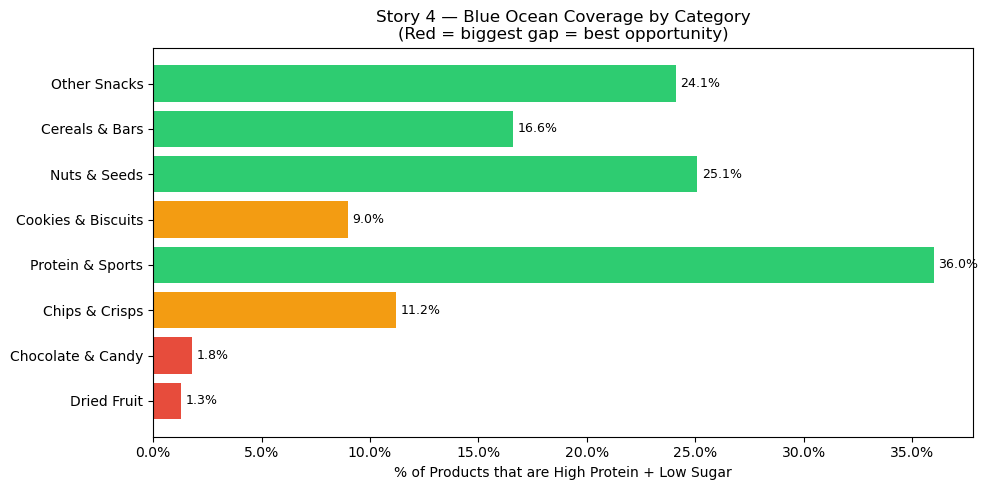

In [ ]:
# Finally, let's visualize the Blue Ocean coverage by category with a horizontal bar chart, coloring the bars based on the percentage of Blue Ocean products to highlight the biggest gaps (red = lowest % = best opportunity)
fig, ax = plt.subplots(figsize=(10, 5))
# we create a horizontal bar chart to show the percentage of Blue Ocean products in each category, coloring the bars to visually highlight which categories have the biggest gaps (red = lowest % = best opportunity)
colors_bo = ['#e74c3c' if p < 5 else '#f39c12' if p < 15 else '#2ecc71'
             for p in bo_by_cat['pct_blue_ocean']]
bars = ax.barh(bo_by_cat.index, bo_by_cat['pct_blue_ocean'], color=colors_bo)
# we can also add the exact percentage values on the bars for clarity
for bar, val in zip(bars, bo_by_cat['pct_blue_ocean']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', fontsize=9)

ax.set_xlabel('% of Products that are High Protein + Low Sugar')
ax.set_title('Story 4 — Blue Ocean Coverage by Category\n(Red = biggest gap = best opportunity)', fontsize=12)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig('s4_blue_ocean_by_category.png', dpi=150, bbox_inches='tight')# we save the Blue Ocean coverage chart for reference, which can be used to visually identify which category has the biggest gap in high protein + low sugar products and therefore represents the best opportunity for a new product launch
plt.show()

---
## Bonus:  The "Hidden Gem"
> Which ingredients drive high protein in the Blue Ocean products?

In [13]:
# To wrap up, let's analyze the ingredients of the Blue Ocean products to identify the most common protein sources used, which can inform potential ingredient choices for a new product in this space
import re
from collections import Counter

# we define a list of common protein sources to look for in the ingredients text of the Blue Ocean products, which can help identify popular ingredients and potential gaps in the market
PROTEIN_SOURCES = [
    'whey', 'pea protein', 'soy protein', 'casein',
    'peanut', 'almond', 'cashew', 'sunflower seed',
    'egg', 'chicken', 'milk protein', 'hemp protein',
    'rice protein', 'lentil', 'chickpea', 'quinoa',
    'pumpkin seed', 'chia', 'flaxseed', 'sesame',
]
# we can analyze the ingredients_text of the Blue Ocean products to count how many times each common protein source appears, which can reveal which ingredients are most popular in this segment and identify any underutilized sources
high_protein_products = df[
    df['is_blue_ocean'] & df['ingredients_text'].notna()
]['ingredients_text'].str.lower()
# we use a Counter to tally the occurrences of each protein source in the ingredients of the Blue Ocean products
source_counts = Counter()
for ingredients in high_protein_products:
    for source in PROTEIN_SOURCES:
        if source in ingredients:
            source_counts[source] += 1

top_sources = pd.DataFrame(
    source_counts.most_common(10),
    columns=['protein_source', 'product_count']
)
# we can also calculate the percentage of Blue Ocean products that contain each protein source to understand their prevalence in this segment
top_sources['pct_of_blue_ocean'] = (top_sources['product_count'] / blue_ocean_total * 100).round(1)
print('Top protein sources in Blue Ocean products:')
print(top_sources.to_string(index=False))

Top protein sources in Blue Ocean products:
protein_source  product_count  pct_of_blue_ocean
       chicken            702                4.4
           egg            513                3.2
          whey            487                3.0
        sesame            330                2.1
   soy protein            309                1.9
        peanut            191                1.2
sunflower seed            164                1.0
        almond            158                1.0
        lentil            105                0.7
      flaxseed            102                0.6


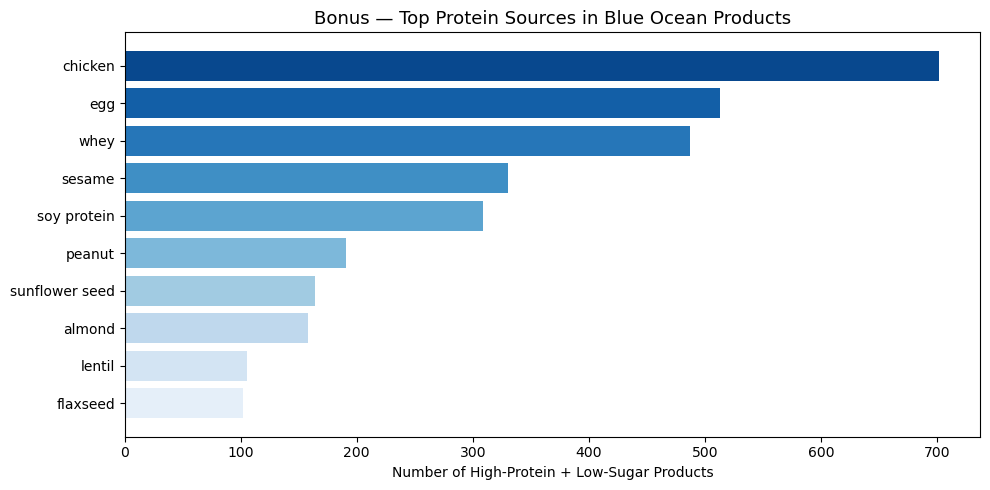


Top 3 protein sources to use in the new recipe: chicken, egg, whey


In [ ]:
# we can visualize the top protein sources with a horizontal bar chart to see which ingredients are most commonly used in the high protein + low sugar products, which can inform ingredient choices for a new product
if not top_sources.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(top_sources['protein_source'], top_sources['product_count'],
            color=sns.color_palette('Blues_r', len(top_sources)))
    ax.set_xlabel('Number of High-Protein + Low-Sugar Products')
    ax.set_title('Bonus — Top Protein Sources in Blue Ocean Products', fontsize=13)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('bonus_protein_sources.png', dpi=150, bbox_inches='tight')# we save the chart of top protein sources for reference, which can be used to identify which ingredients are most popular in the Blue Ocean segment and potentially underutilized sources that could differentiate a new product
    plt.show()

    top3 = top_sources['protein_source'].head(3).tolist()
    print(f'\nTop 3 protein sources to use in the new recipe: {", ".join(top3)}')
else:# if there are no Blue Ocean products with ingredient data, we can't analyze the protein sources, which suggests that this segment is very under-served and could be a great opportunity for innovation
    print('No ingredient data available in this subset — try with more rows.')

---
## Candidate's Choice:  Nutri-Score Landscape by Category

**Business-Justification:**  

The Nutri-Score (A–E) is a standardised front-of-pack label increasingly mandated across Europe and
adopted voluntarily by global manufacturers. Knowing which categories are dominated by D/E-rated
products tells the client *exactly* where a superior-rated product would immediately stand out on
shelf  turning the health audit into a specific retail strategy, not just an R&D brief.

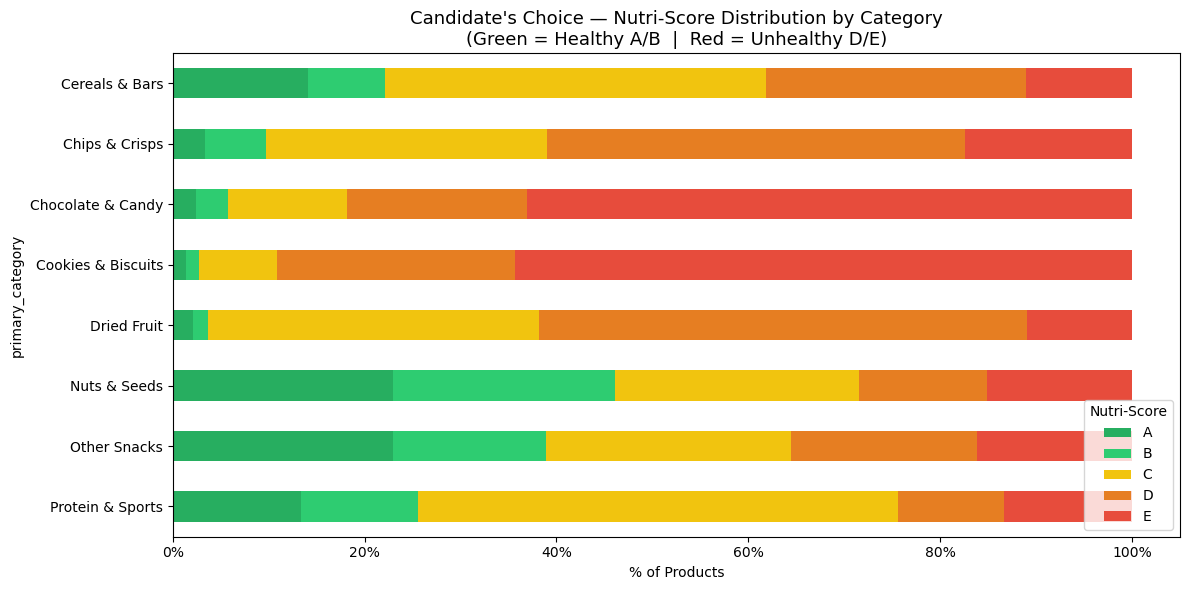


Category most dominated by D/E products: Cookies & Biscuits (89.2%)
A new A/B-rated product here would face the least healthy competition on shelf.


In [ ]:
# Finally, let's analyze the Nutri-Score distribution by category to see which categories have the healthiest vs. unhealthiest products, which can further inform our choice of category for a new product that aims to be a healthier option on shelf
if 'nutriscore_grade' in df.columns:
    nutri = (
        df
        .dropna(subset=['nutriscore_grade'])
        .assign(nutriscore_grade=lambda d: d['nutriscore_grade'].str.upper().str.strip())
        .query('nutriscore_grade in ["A","B","C","D","E"]')
    )
# we create a pivot table to count the number of products in each primary category for each Nutri-Score grade, which allows us to see the distribution of healthiness across categories
    nutri_pivot = (
        nutri
        .groupby(['primary_category', 'nutriscore_grade'])
        .size()
        .unstack(fill_value=0)
    )
   
    # we convert the counts to percentages within each category to compare the healthiness distribution across categories, which can reveal which categories are dominated by healthier (A/B) vs. unhealthier (D/E) products
    nutri_pct = nutri_pivot.div(nutri_pivot.sum(axis=1), axis=0) * 100
    nutri_pct = nutri_pct.reindex(columns=['A','B','C','D','E'], fill_value=0)

    grade_colors = {'A': '#27ae60', 'B': '#2ecc71', 'C': '#f1c40f', 'D': '#e67e22', 'E': '#e74c3c'}

    ax = nutri_pct.plot(
        kind='barh',
        stacked=True,
        figsize=(12, 6),
        color=[grade_colors[g] for g in nutri_pct.columns],
    )# we create a stacked horizontal bar chart to show the percentage distribution of Nutri-Score grades within each category, which visually highlights which categories have more healthy (A/B) vs. unhealthy (D/E) products
    ax.set_xlabel('% of Products')
    ax.set_title("Candidate's Choice — Nutri-Score Distribution by Category\n"
                 "(Green = Healthy A/B  |  Red = Unhealthy D/E)", fontsize=13)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title='Nutri-Score', loc='lower right')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('candidates_choice_nutriscore.png', dpi=150, bbox_inches='tight')# we save the Nutri-Score distribution chart for reference, which can be used to identify which category has the least healthy competition (highest share of D/E products) for a new A/B-rated product
    plt.show()

    # Which category has the highest share of D+E products?
    nutri_pct['pct_unhealthy'] = nutri_pct.get('D', 0) + nutri_pct.get('E', 0)
    worst_cat = nutri_pct['pct_unhealthy'].idxmax()
    worst_val = nutri_pct.loc[worst_cat, 'pct_unhealthy']
    print(f'\nCategory most dominated by D/E products: {worst_cat} ({worst_val:.1f}%)')
    print('A new A/B-rated product here would face the least healthy competition on shelf.')
else:
    print('nutriscore_grade column not present in this subset — run with more columns to enable.')

## Export: Power BI / Dashboard CSV

In [16]:
export_cols = [
    'product_name',
    'primary_category',
    'sugars_100g',
    'proteins_100g',
    'fat_100g',
    'fiber_100g',
    'energy_100g',
    'is_blue_ocean',
]# we prepare a final dataset for export that includes the key columns needed for further analysis in Power BI, including the assigned primary category and Blue Ocean flag
if 'nutriscore_grade' in df.columns:
    export_cols.append('nutriscore_grade')
# we export the cleaned and enriched dataset to a CSV file that can be easily imported into Power BI for dashboard creation and further analysis
export_df = df[export_cols].copy()
export_df.to_csv('sugar_trap_master_dataset.csv', index=False)
print(f'Exported sugar_trap_master_dataset.csv — {len(export_df):,} rows')

# Category summary for Power BI KPI cards
# we also create a summary dataset that aggregates key metrics by primary category, which can be used to create KPI cards and category-level insights in Power BI
summary = (
    df.groupby('primary_category')
    .agg(
        total_products=('product_name', 'count'),
        avg_sugar=('sugars_100g', 'mean'),
        avg_protein=('proteins_100g', 'mean'),
        blue_ocean_count=('is_blue_ocean', 'sum'),
    )
    .assign(pct_blue_ocean=lambda d: (d['blue_ocean_count'] / d['total_products'] * 100).round(1))
    .round(2)
    .reset_index()
)# we export the category summary to a separate CSV file for easy import into Power BI, which can be used to create category-level KPIs and visualizations
summary.to_csv('sugar_trap_category_summary.csv', index=False)
print('Exported sugar_trap_category_summary.csv')
print('\nReady to import into Power BI.')

Exported sugar_trap_master_dataset.csv — 74,468 rows
Exported sugar_trap_category_summary.csv

Ready to import into Power BI.
